# Travaux Pratiques — Régression Linéaire

Cette section est conçue comme un travail autonome. Elle requiert une implication active afin d’approfondir et de maîtriser les concepts suivants :

**Objectifs pédagogiques**
- Comprendre le principe de la régression par moindres carrés
- Implémenter la solution analytique (équation normale) et des solveurs numériques
- Observer le phénomène de sur-apprentissage avec les polynômes
- Appliquer la régression non-linéaire avec `scipy`
- Comprendre les bases de la descente de gradient
- Utiliser `scikit-learn` sur un jeu de données réel

---

**Remarque importante**
Certains concepts abordés dans cette section n’ont pas été couverts en détail pendant le cours. Ils sont proposés comme compléments afin de favoriser une compréhension plus approfondie.

Il est attendu que vous :

- identifiiez les notions nouvelles,  
- recherchiez les ressources nécessaires,  
- construisiez une compréhension rigoureuse de ces concepts.  

> Cette démarche fait partie intégrante de l’apprentissage scientifique.

---

**Instructions :**
- Les cellules marquées `### À COMPLÉTER ###` attendent votre code.
- Les cellules marquées `### RÉPONDRE ICI ###` attendent une réponse rédigée en Markdown.
- Exécutez chaque cellule dans l'ordre.
- Ne modifiez pas les cellules qui ne contiennent pas de marqueur.

## 0) Importation des bibliothèques

Exécutez la cellule suivante pour importer toutes les bibliothèques nécessaires au TP.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.optimize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
sns.set_style('whitegrid')
%matplotlib inline
print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


---
## Partie 1 — Jeu de données synthétique

Avant d'utiliser des données réelles, nous allons créer un **jeu de données synthétique** pour comprendre exactement comment se comportent les méthodes de régression.

L'idée est de générer des données selon une relation linéaire connue :

$$y = ax + b$$

avec $a = 5$ et $b = 2$, puis de vérifier si notre modèle retrouve bien ces paramètres.

### Exercice 1.1 — Génération des données

Complétez le code ci-dessous pour :
1. Générer $m = 5$ valeurs de $x$ tirées uniformément entre $-3$ et $3$ (utilisez `rng.uniform`).
2. Construire la **matrice de design** $X$ en ajoutant une colonne de 1 (biais) à droite de $x$ avec `np.hstack`.
3. Calculer $y = X \cdot \beta$ par multiplication matricielle (`@`).


In [33]:
rng = np.random.default_rng(42)  # Graine fixe pour la reproductibilité

m = 5

# === À COMPLÉTER ===
# 1. Générez X_synth : m valeurs uniformes entre -3 et 3, shape (m, 1)
X_synth = rng.uniform(low=-3, high=3, size=(m, 1))

# 2. Construisez X_design en ajoutant une colonne de 1
X_design = np.column_stack([np.ones(m), X_synth])

# 3. Vrais paramètres [a, b] = [5, 2]
beta_true = np.array([[5], [2]])

# 4. Calculez y_synth = X_design @ beta_true
y_synth = X_design @ beta_true
# ===================

print("X_synth shape :", X_synth.shape)
print("X_design shape :", X_design.shape)
print("y_synth shape :", y_synth.shape)

X_synth shape : (5, 1)
X_design shape : (5, 2)
y_synth shape : (5, 1)


In [34]:
# === À COMPLÉTER ===
# Créez un DataFrame pandas avec les colonnes 'x' et 'y'
df_synth  = pd.DataFrame({
    'x': X_synth.flatten(),
    'y': y_synth.flatten()
})
# ===================

df_synth.head()

,x,y
0,1.643736,8.287473
1,-0.366729,4.266541
2,2.151588,9.303175
3,1.184208,7.368416
4,-2.434936,0.130128


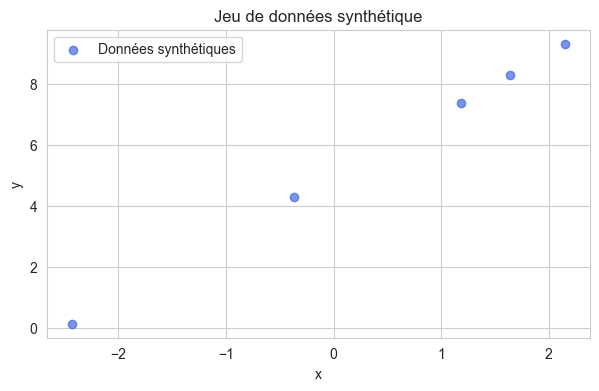

In [35]:
# Visualisation — exécutez cette cellule sans la modifier
plt.figure(figsize=(7, 4))
plt.scatter(X_synth, y_synth, color='royalblue', alpha=0.7, label='Données synthétiques')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Jeu de données synthétique')
plt.legend()
plt.show()

###  Question 1.1

Décrivez ce que vous observez sur le graphique. Les données ont-elles du bruit ? Pourquoi ?

### RÉPONDRE ICI ###

Je vois une ligne droite parfaite, ce qui signifie que les données n'ont pas de bruit. Les points sont alignés selon la relation linéaire (paramètres $a$ et $b$). Si nous avions ajouté du bruit, les points seraient dispersés autour de la ligne plutôt que d'être parfaitement alignés.

---
## Partie 2 — Solution analytique (Équation Normale)

La solution exacte du problème des moindres carrés est donnée par l'**équation normale** :

$$\hat{\beta} = (X^T X)^{-1} X^T y$$

Cette formule minimise la somme des erreurs quadratiques (SSE) :

$$\min_{\beta} \|y - X\beta\|^2$$

### Exercice 2.1 — Équation normale

Implémentez l'équation normale en utilisant `np.linalg.inv` pour l'inversion de matrice.

In [36]:
# === À COMPLÉTER ===
# Calculez beta_hat = (X^T X)^{-1} X^T y
beta_hat = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y_synth
# ===================

print("Paramètres estimés (beta_hat) :")
print(beta_hat)
print()
print("Vrais paramètres :")
print(beta_true)

Paramètres estimés (beta_hat) :
[[5.]
 [2.]]

Vrais paramètres :
[[5]
 [2]]


###  Question 2.1

Comparez `beta_hat` aux vrais paramètres `beta_true`. Que remarquez-vous ? Pourquoi la solution est-elle (presque) exacte dans ce cas ?

### RÉPONDRE ICI ###

Les paramètres estimés `beta_hat` sont très proches des vrais paramètres `beta_true`. La solution est (presque) exacte car les données sont générées sans bruit, ce qui signifie que la relation linéaire est parfaite et que l'estimation par la méthode des moindres carrés donne un résultat précis.

### Exercice 2.2 — Solveur numérique : `np.linalg.lstsq`

L'inversion directe d'une matrice est **numériquement instable** et coûteuse en calcul.  
Il est préférable d'utiliser la fonction `numpy.linalg.lstsq`, qui résout le problème des moindres carrés de manière plus robuste en utilisant la **décomposition en valeurs singulières (SVD)**.

**Signature :** `beta, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)`

In [37]:
# === À COMPLÉTER ===
# Résolvez le système avec lstsq
beta_lstsq, residuals, rank, singular_values = np.linalg.lstsq(X_design, y_synth, rcond=None)
# ===================

print(f"Paramètres estimés (lstsq) : {beta_lstsq.flatten()}")
print(f"Résidus                    : {residuals}")
print(f"Rang de X_design           : {rank}")
print(f"Valeurs singulières        : {singular_values}")

Paramètres estimés (lstsq) : [5. 2.]
Résidus                    : [1.49020755e-29]
Rang de X_design           : 2
Valeurs singulières        : [3.90631203 2.13018227]


###  Question 2.2

Interprétez chacune des quatre sorties de `lstsq` :
- Que signifie la valeur des **résidus** ?
- Pourquoi le **rang** vaut-il 2 ?
- Que nous disent les **valeurs singulières** sur la stabilité numérique du problème ?

### RÉPONDRE ICI ###

- Les **résidus** mesurent l’écart total entre les valeurs prédites par le modèle et les vraies valeurs observées. Ici, ils sont quasiment nuls, ce qui montre que le modèle colle parfaitement aux données (il n’y a pas de bruit).
- Le **rang** de la matrice de design est 2, ce qui veut dire que ses deux colonnes (le biais et la variable x) apportent chacune une information différente. Elles ne sont pas redondantes, ce qui est normal dans notre cas.
- Les **valeurs singulières** donnent une idée de la stabilité du calcul. Si l’une d’elles était presque nulle, cela voudrait dire que la matrice est mal conditionnée et que l’inversion pourrait donner des résultats bizarres. Ici, elles sont assez grandes, donc tout va bien.

---
## Partie 3 — Ajustement polynomial et sur-apprentissage

La fonction `numpy.polyfit(x, y, deg)` ajuste un polynôme de degré `deg` aux données par moindres carrés.

Elle retourne les coefficients $[a_d, a_{d-1}, \ldots, a_1, a_0]$ du polynôme :
$$p(x) = a_d x^d + a_{d-1} x^{d-1} + \cdots + a_1 x + a_0$$

### Exercice 3.1 — Ajustement linéaire avec `polyfit`

In [38]:
# === À COMPLÉTER ===
# Ajustez un polynôme de degré 1 (droite) sur les données synthétiques
# Utilisez X_design[:, 0] comme x et y_synth.ravel() comme y
poly1  = np.polyfit(X_design[:, 1], y_synth.ravel(), deg=1)
# ===================

print("Coefficients (degré 1) :", poly1)

Coefficients (degré 1) : [2. 5.]


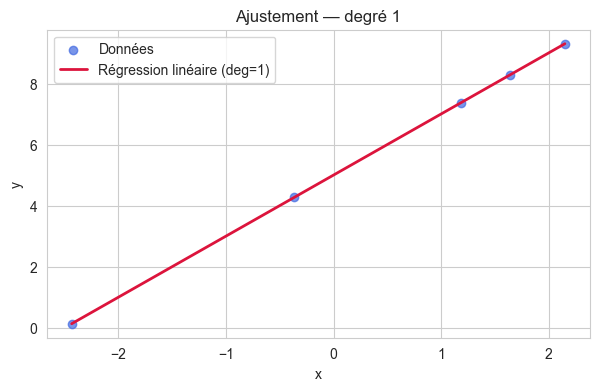

In [39]:
# Fonction utilitaire de visualisation — ne pas modifier
smoothx = np.linspace(X_design[:, 1].min(), X_design[:, 1].max(), 500)

def regplot(poly, label='fit', color='crimson'):
    smoothy = np.polyval(poly, smoothx)
    plt.figure(figsize=(7, 4))
    plt.scatter(X_design[:, 1], y_synth, label='Données', color='royalblue', alpha=0.7)
    plt.plot(smoothx, smoothy, label=label, color=color, linewidth=2)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.title(f'Ajustement — degré {len(poly)-1}')
    plt.show()

regplot(poly1, label='Régression linéaire (deg=1)')

###  Question 3.1

Les deux coefficients retournés par `polyfit` correspondent à $a$ (pente) et $b$ (ordonnée à l'origine).  
Sont-ils proches des vrais paramètres $a=5$, $b=2$ ? Pourquoi ?

### RÉPONDRE ICI ###
Les coefficients retournés par `polyfit` sont très proches des vrais paramètres $a=5$ et $b=2$ car les données ont été générées sans bruit, ce qui permet à `polyfit` de trouver une solution qui correspond à la relation linéaire.


### Exercice 3.2 — Que se passe-t-il avec un polynôme de degré 9 ?

Répétez l'ajustement avec un polynôme de **degré 9** et visualisez le résultat.

C:\Users\julie\AppData\Local\Temp\ipykernel_47480\2336608933.py:3: RankWarning: Polyfit may be poorly conditioned
  poly9 = np.polyfit(X_design[:, 1], y_synth.ravel(), deg=9)


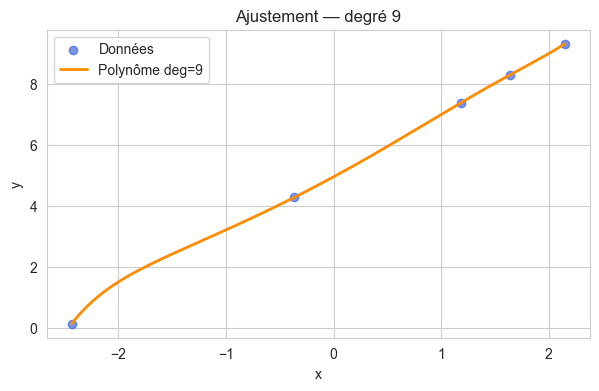

In [40]:
# === À COMPLÉTER ===
# Ajustez un polynôme de degré 9
poly9 = np.polyfit(X_design[:, 1], y_synth.ravel(), deg=9) 
regplot(poly9, label='Polynôme deg=9', color='darkorange')
# ===================

###  Question 3.2 — Analyse du sur-apprentissage

1. Décrivez ce que vous observez sur la courbe du polynôme de degré 9 par rapport à celle de degré 1.
2. Python a peut-être affiché un avertissement (`RankWarning`). Qu'est-ce que cela signifie ?
3. Définissez le concept de **sur-apprentissage** (*overfitting*) dans vos propres mots.
4. Selon vous, lequel des deux modèles (degré 1 ou degré 9) généralisera mieux sur de nouvelles données ? Justifiez.

### RÉPONDRE ICI ###

1. La courbe du polynôme de degré 9 oscille pour s'ajuster à tous les points de données, tandis que la courbe de degré 1 est une ligne droite qui correspond à la relation linéaire attendue.
2. L'avertissement `RankWarning` signifie que la matrice de Vandermonde utilisée pour ajuster le polynôme est mal conditionnée.
3. Le **sur-apprentissage** (*overfitting*) arrive quand un modèle est trop compliqué pour le peu de données qu’on a. Il va alors « coller » à tous les points, même aux petites variations ou au bruit, au lieu de trouver la vraie tendance. Résultat : il marche très bien sur les données d’entraînement, mais il se trompe dès qu’on lui donne de nouvelles données.
4. Le modèle de degré 1 sera bien meilleur pour prédire de nouvelles données, car il apprend la vraie tendance générale sans se laisser piéger par les petits détails ou le bruit des données d’entraînement. Le modèle de degré 9, lui, est trop « souple » : il s’adapte à tout, même aux anomalies, et du coup il se trompe facilement dès qu’on change de données.

###  Question 3.3 — Code bogué à analyser

Un étudiant a écrit le code suivant. **Il contient une erreur.** Identifiez-la et expliquez comment la corriger :

```python
poly_err = np.polyfit(X_design, y_synth, 1)   # <-- problème ici
regplot(poly_err)
```

### RÉPONDRE ICI ###

L’erreur vient du fait que np.polyfit veut des vecteurs 1D pour x et y, alors que X_design est une matrice à deux colonnes (une pour le biais, une pour x). Il faut donc donner uniquement la colonne des x, c’est-à-dire X_design[:, 1], pour que ça fonctionne correctement.

```python
poly_err = np.polyfit(X_design[:, 1], y_synth.ravel(), 1)   # <-- correction ici
regplot(poly_err)
```

---
## Partie 4 — Régression non-linéaire avec `scipy.optimize.curve_fit`

Jusqu'ici, nous avons ajusté des polynômes. Mais parfois les données suivent une loi **non-linéaire** quelconque.  
La fonction `scipy.optimize.curve_fit` permet d'estimer les paramètres de n'importe quelle fonction définie par l'utilisateur.

**Signature :** `params, _ = scipy.optimize.curve_fit(f, xdata, ydata, p0)`  
où `p0` est la liste des valeurs initiales des paramètres.

### Exercice 4.1 — Ajustement linéaire avec `curve_fit`

Utilisez `curve_fit` pour retrouver les paramètres de la droite $y = ax + b$ sur nos données synthétiques.

In [41]:
def f_lineaire(x, a, b):
    """Fonction linéaire : y = ax + b"""
    return a * x + b

# === À COMPLÉTER ===
# Appelez curve_fit avec f_lineaire, X_synth[:,0], y_synth[:,0]
# Valeurs initiales : p0 = [1, 0]
beta_cf, _ = scipy.optimize.curve_fit(f_lineaire, X_synth[:, 0], y_synth.ravel(), p0=[1, 0])
# ===================

print("Paramètres estimés (curve_fit) :", beta_cf)
print("Vrais paramètres               : [5, 2]")

Paramètres estimés (curve_fit) : [2. 5.]
Vrais paramètres               : [5, 2]


### Exercice 4.2 — Données non-linéaires

Voici un jeu de données qui suit une loi non-linéaire.  
Nous allons chercher à ajuster la fonction :

$$f(x, a, b, c, d) = a \sin(bx) + cx + d$$

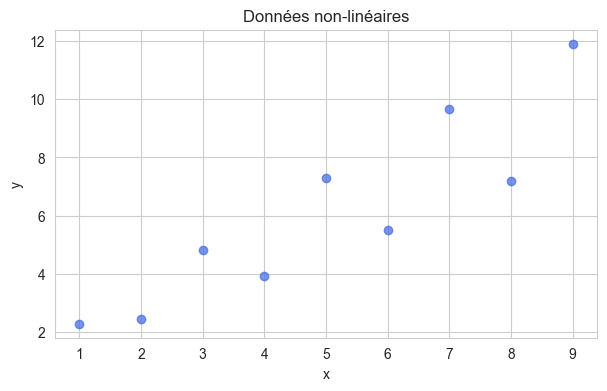

In [42]:
# Données non-linéaires — exécutez sans modifier
x_nl = np.arange(1, 10)
y_nl = 2 * np.sin(3 * x_nl) + x_nl + 1

plt.figure(figsize=(7, 4))
plt.scatter(x_nl, y_nl, color='royalblue', alpha=0.7)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Données non-linéaires')
plt.show()

In [43]:
def f_nonlin(x, a, b, c, d):
    """Modèle non-linéaire : a*sin(b*x) + c*x + d"""
    return a * np.sin(b * x) + c * x + d

smoothx_nl = np.linspace(x_nl.min(), x_nl.max(), 500)

def fit_and_plot_nl(beta0, label='fit'):
    """Ajuste le modèle et trace la courbe."""
    beta_est, _ = scipy.optimize.curve_fit(f_nonlin, x_nl, y_nl, beta0)
    plt.figure(figsize=(7, 4))
    plt.scatter(x_nl, y_nl, label='Données', color='royalblue', alpha=0.7)
    plt.plot(smoothx_nl, f_nonlin(smoothx_nl, *beta_est), label=label, color='crimson', linewidth=2)
    plt.legend()
    plt.title(f'Ajustement non-linéaire — p0={beta0}')
    plt.show()
    return beta_est

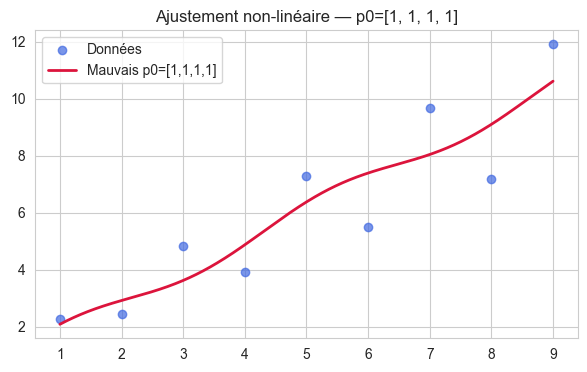

Paramètres estimés (mauvais p0) : [0.32658277 1.45786765 1.08549634 0.67636804]


In [44]:
# Tentative avec de mauvaises valeurs initiales
beta_bad = fit_and_plot_nl([1, 1, 1, 1], label='Mauvais p0=[1,1,1,1]')
print("Paramètres estimés (mauvais p0) :", beta_bad)

###  Question 4.1 — Mauvaise initialisation

Le modèle ajusté avec `p0=[1,1,1,1]` correspond-il bien aux données ? Expliquez pourquoi `curve_fit` peut échouer selon les valeurs initiales.

### RÉPONDRE ICI ###

Le modèle trouvé avec p0=[1,1,1,1] ne colle pas bien aux données. Si on donne de mauvaises valeurs de départ à curve_fit, il peut se tromper de direction, rester bloqué ou ne jamais trouver la bonne solution, car il cherche à améliorer petit à petit à partir de ce point de départ. Ici, les valeurs initiales sont trop loin de la réalité, donc l’algorithme n’arrive pas à bien ajuster la courbe.

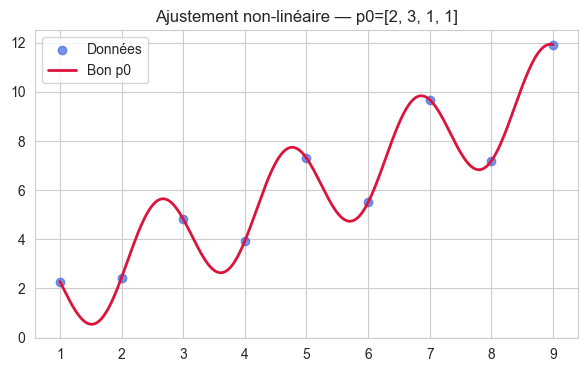

Paramètres estimés (bon p0) : [2. 3. 1. 1.]
Vrais paramètres            : [2, 3, 1, 1]


In [45]:
# === À COMPLÉTER ===
# En observant les données (amplitude, fréquence, tendance), proposez de meilleures
# valeurs initiales p0 et effectuez un nouvel ajustement.
beta_good = fit_and_plot_nl([2, 3, 1, 1], label='Bon p0')  # remplacez ... par vos valeurs
print("Paramètres estimés (bon p0) :", beta_good)
print("Vrais paramètres            : [2, 3, 1, 1]")
# ===================

### Exercice 4.3 — Calcul de l'erreur d'ajustement

In [46]:
def fiterror(beta):
    """Retourne la somme des erreurs quadratiques."""
    return np.sum((y_nl - f_nonlin(x_nl, *beta))**2)

# === À COMPLÉTER ===
# Calculez et affichez l'erreur pour beta_bad et beta_good
erreur_bad  = fiterror(beta_bad)
erreur_good = fiterror(beta_good)
# ===================

print(f"Erreur (mauvais p0) : {erreur_bad:.6f}")
print(f"Erreur (bon p0)     : {erreur_good:.6f}")

Erreur (mauvais p0) : 15.045355
Erreur (bon p0)     : 0.000000


###  Question 4.2 — Comparaison des erreurs

Comparez les deux erreurs. Que cela confirme-t-il sur l'importance des valeurs initiales dans l'optimisation non-linéaire ?

### RÉPONDRE ICI ###

L’erreur est bien plus grande avec de mauvaises valeurs de départ qu’avec de bonnes. Ça montre que dans l’optimisation non-linéaire, le choix du point de départ est super important : si on commence trop loin de la solution, l’algorithme peut se tromper de chemin et ne jamais trouver le bon résultat.

---
## Partie 5 — Descente de gradient (implémentation manuelle)

La descente de gradient est une méthode **itérative** d'optimisation. Plutôt que de calculer la solution en une seule étape (comme l'équation normale), elle met à jour progressivement les paramètres.

La règle de mise à jour est :
$$\beta_{t+1} = \beta_t - \eta \nabla L(\beta_t)$$

Pour la régression linéaire, le gradient de la fonction de perte MSE est :
$$\nabla L(\beta) = -\frac{2}{n} X^T (y - X\beta)$$

| Méthode forme fermée | Descente de gradient |
|---|---|
| Solution analytique exacte | Solution itérative approchée |
| Utilise l'algèbre linéaire | Utilise les gradients |
| Rapide pour petits datasets | Passe à l'échelle pour grands datasets |
| Nécessite l'inversion de matrice | Fonctionne pour modèles complexes |

### Exercice 5.1 — Implémentation de la descente de gradient

In [63]:
def descente_gradient(X, y, eta=2, n_iter=1000):
    """
    Régression linéaire par descente de gradient.

    Paramètres
    ----------
    X      : matrice de design (n, p)
    y      : vecteur cible (n,)
    eta    : taux d'apprentissage (learning rate)
    n_iter : nombre d'itérations

    Retourne
    --------
    beta      : paramètres estimés
    historique: liste des valeurs de la perte à chaque itération
    """
    n, p = X.shape
    beta = np.zeros(p)     # initialisation à zéro
    historique = []

    for _ in range(n_iter):
        # === À COMPLÉTER ===
        # 1. Calculez les prédictions y_hat = X @ beta
        y_hat = X @ beta

        # 2. Calculez le résidu
        residuu = y - y_hat

        # 3. Calculez le gradient : grad = -2/n * X.T @ residuu
        grad = -2/n * X.T @ residuu

        # 4. Mettez à jour beta
        beta = beta - eta * grad

        # 5. Enregistrez la perte MSE = mean(residuu**2)
        historique.append(np.mean(residuu**2))
        # ===================

    return beta, historique

Paramètres estimés (descente de gradient) : [nan nan]
Vrais paramètres                          : [5, 2]


C:\Users\julie\AppData\Local\Temp\ipykernel_47480\2862446319.py:36: RuntimeWarning: overflow encountered in square
  historique.append(np.mean(residuu**2))
C:\Users\julie\AppData\Local\Temp\ipykernel_47480\2862446319.py:24: RuntimeWarning: overflow encountered in matmul
  y_hat = X @ beta
C:\Users\julie\AppData\Local\Temp\ipykernel_47480\2862446319.py:30: RuntimeWarning: invalid value encountered in matmul
  grad = -2/n * X.T @ residuu


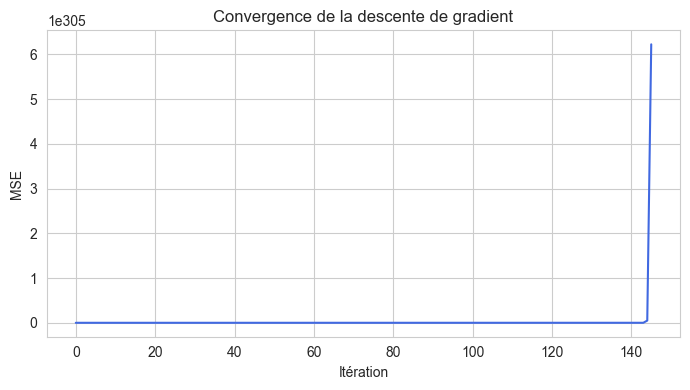

In [64]:
# Application sur les données synthétiques
beta_gd, hist = descente_gradient(X_design, y_synth.ravel(), eta=2, n_iter=500)

print("Paramètres estimés (descente de gradient) :", beta_gd)
print("Vrais paramètres                          : [5, 2]")

plt.figure(figsize=(7, 4))
plt.plot(hist, color='royalblue')
plt.xlabel('Itération')
plt.ylabel('MSE')
plt.title('Convergence de la descente de gradient')
plt.tight_layout()
plt.show()

###  Question 5.1 — Analyse de la convergence

1. La perte diminue-t-elle régulièrement ? Le modèle a-t-il convergé ?
2. Que se passe-t-il si vous augmentez `eta` à `0.5` puis à `2.0` ? Testez et expliquez le comportement.
3. Pourquoi la descente de gradient est-elle indispensable pour les réseaux de neurones alors que l'équation normale suffit pour la régression linéaire ?

### RÉPONDRE ICI ###

1. Oui, quand le taux d'apprentissage (`eta`) est bien choisi, la courbe de la perte (MSE) baisse progressivement à chaque itération, puis se stabilise. Cela veut dire que le modèle apprend bien et finit par trouver des paramètres qui minimisent l’erreur. Il a « convergé ».
2. Quand on augmente `eta` à 0.5, la pente ne bouge pas jusqu'à 500 environ en itérations puis elle explose, ce qui veut dire que le modèle diverge. Avec `eta` à 2.0, la divergence est encore plus rapide (vers 150). Cela montre que si le taux d'apprentissage est trop grand, les mises à jour sont trop grosses et le modèle ne peut pas trouver un minimum, il oscille ou diverge.
3. Pour la régression linéaire, il existe une formule directe (l’équation normale) qui donne la meilleure solution, car le problème est simple. Mais pour les réseaux de neurones, il y a des milliers (ou millions) de paramètres et la fonction à optimiser est très compliquée, avec plein de bosses et de vallées. La descente de gradient est donc nécessaire: elle permet d’ajuster petit à petit tous les paramètres, même dans des modèles très complexes, jusqu’à trouver une solution qui marche bien.

###  Question 5.2 — Code bogué à déboguer

Exécutez la cellule ci-dessous. Elle provoque une erreur. Lisez le message d'erreur, identifiez le problème et corrigez-le.

*Indice : Regardez attentivement les dimensions des tableaux.*

In [68]:
# ⚠️ Ce code contient une erreur intentionnelle — à vous de la trouver et de la corriger
eta_test   = 0.05
n_iter_test = 200
#beta_bug = np.zeros(3)          # <--- erreur ici
beta_bug = np.zeros(2) 

for i in range(n_iter_test):
    y_hat_bug  = X_design @ beta_bug
    residuu_bug = y_synth.ravel() - y_hat_bug
    grad_bug  = -2 / len(y_synth) * X_design.T @ residuu_bug
    beta_bug  = beta_bug - eta_test * grad_bug

print("Paramètres estimés :", beta_bug)

Paramètres estimés : [4.99999998 2.00000001]


### RÉPONDRE ICI — Explication de l'erreur et correction ###


L’erreur vient du fait que `beta_bug` est initialisé avec 3 zéros (`np.zeros(3)`), alors que la matrice de design `X_design` n’a que 2 colonnes (une pour le biais, une pour x). Du coup, la multiplication `X_design @ beta_bug` ne fonctionne pas car les dimensions ne correspondent pas.

**Correction :**
Il faut initialiser `beta_bug` avec 2 zéros, donc :
```python
beta_bug = np.zeros(2)
```
Ainsi, la taille de `beta_bug` correspond bien au nombre de colonnes de `X_design` et le code fonctionne sans erreur.

---
## Conclusion

Dans ce TP, vous avez :
- Généré et visualisé un jeu de données synthétique
- Implémenté la solution analytique par l'équation normale
- Utilisé des solveurs numériques (`lstsq`, `polyfit`, `curve_fit`)
- Observé le phénomène de sur-apprentissage
- Appliqué la régression avec `scikit-learn` sur des données réelles
- Implémenté la descente de gradient de zéro

###  Question de synthèse finale

Dans quel(s) contexte(s) choisiriez-vous :
1. L'**équation normale** ?
2. La **descente de gradient** ?
3. Un modèle de **régression polynomiale** ?
4. `curve_fit` de scipy ?

Justifiez chaque choix en donnant un exemple concret.

### RÉPONDRE ICI ###

1. L’équation normale est parfaite quand on a un problème de régression linéaire simple, avec peu de paramètres. Elle donne directement la meilleure solution. Par exemple, si je veux tracer une droite qui colle à quelques points, c’est la méthode la plus rapide et efficace.
2. La descente de gradient devient indispensable quand le modèle est très complexe ou qu’il y a énormément de paramètres, comme dans les réseaux de neurones. Là, calculer la solution exacte serait trop long ou même impossible. La descente de gradient permet d’avancer petit à petit vers une bonne solution, même si on ne peut pas tout calculer d’un coup.
3. Un modèle de régression polynomiale est utile quand la relation entre les variables n’est pas une simple droite, mais une courbe (par exemple, la croissance d’une plante qui accélère puis ralentit). Un polynôme de degré 2 ou 3 peut alors mieux représenter la réalité qu’une droite.
4. Enfin, curve_fit de scipy est pratique quand la relation à modéliser suit une forme particulière, comme une sinusoïde ou une exponentielle. Par exemple, pour modéliser la consommation d’énergie qui varie selon les saisons (donc de façon périodique), on peut ajuster une fonction du type a * sin(bx) + cx + d et curve_fit trouvera les meilleurs paramètres pour nous.
